In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import matplotlib.image as mpimg


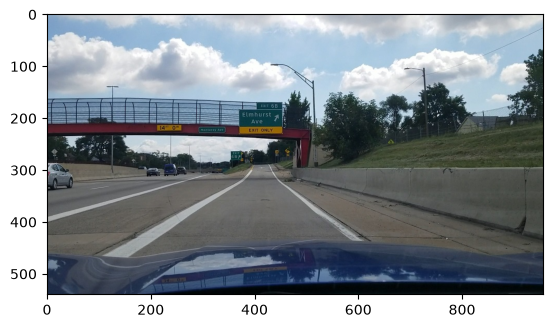

In [2]:
image=mpimg.imread("new_lane.jpg")
plt.imshow(image)

(540, 956)

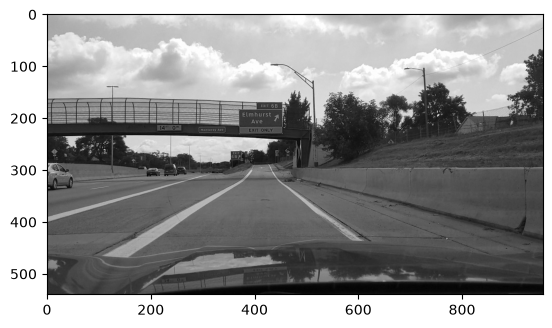

In [3]:
image_g=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
plt.imshow(image_g,cmap='gray')
image_g.shape

Gaussian Blurring and Canny Edge Detection

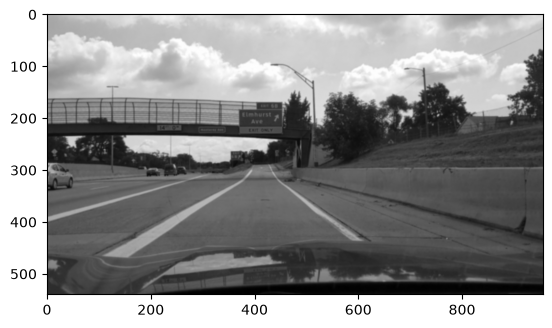

In [40]:
image_blurred=cv2.GaussianBlur(image_g,(5,5),0)
plt.imshow(image_blurred,cmap='gray')

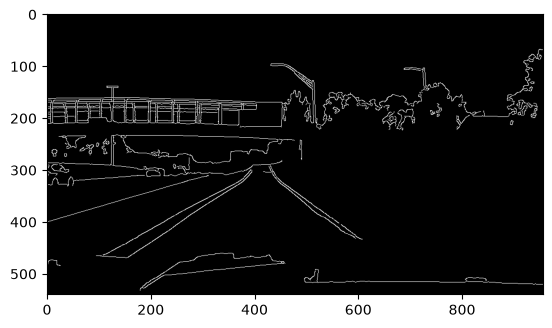

In [18]:
threshold1=10
threshold2=200
image_canny=cv2.Canny(image_blurred,threshold1,threshold2)
plt.imshow(image_canny,cmap='gray')

Defining the Region of Interests

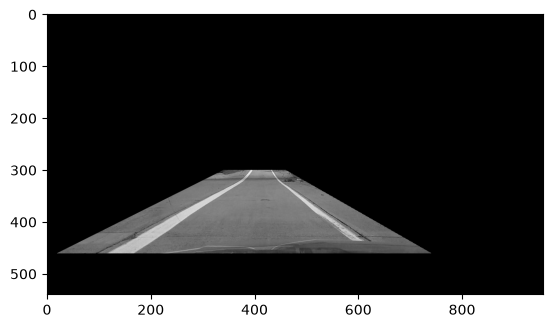

In [21]:
vertical=np.array([[(20,460),(340,300),(460,300),(740,460)]])
mask=np.zeros_like(image_g)
cv2.fillPoly(mask,vertical,255)
masked_image=cv2.bitwise_and(image_g,mask)
plt.figure()
plt.imshow(masked_image,cmap='gray')

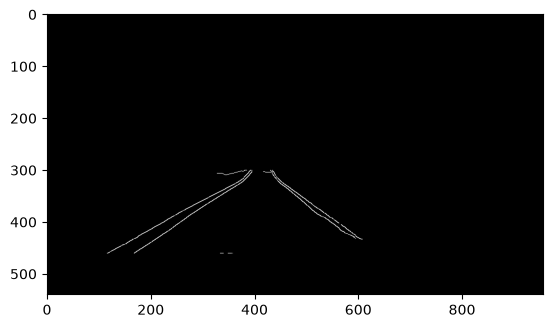

In [23]:
masked_image=cv2.bitwise_and(image_canny,mask)
plt.figure()
plt.imshow(masked_image,cmap='gray')

Hough lines Detection

In [35]:
rho = 2
theta = np.pi/180
threshold = 40

# distance resolution in pixels
# angular resolution in radians
# minimum number of votes
min_line_len = 100 # minimum number of pixels making up a line
max_line_gap = 50 # maximum gap in pixels between connectable line segments
lines = cv2.HoughLinesP(masked_image, rho, theta, threshold, np.array([]), minLineLength=min_line_len, maxLineGap=max_line_gap)

# Create an empty black image
line_image = np. zeros((masked_image.shape[0],masked_image.shape[1],3),dtype=np.uint8)
for x1, y1, x2, y2 in lines:
    cv2.line(line_image, (x1, y1), (x2, y2), (255, 0, 0), 20)
lines

array([[118, 460, 229, 398],
       [169, 460, 388, 312],
       [501, 359, 606, 433],
       [207, 409, 375, 319],
       [420, 303, 578, 422],
       [116, 460, 321, 347],
       [419, 303, 537, 383],
       [273, 388, 379, 321],
       [427, 304, 605, 433]], dtype=int32)

In [38]:
a=1
b=1
c=0
Image_with_line=cv2.addWeighted(image,a,line_image,b,c)

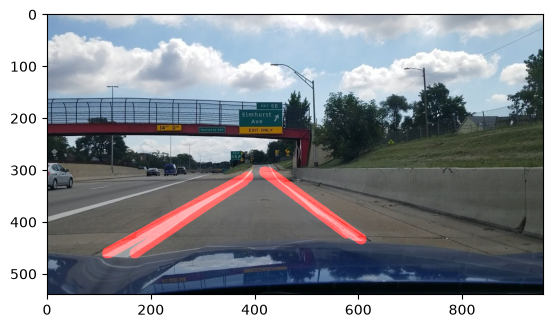

In [39]:
plt.figure()
plt.imshow(Image_with_line)